In [14]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
ticks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "ITC.NS",
    "HINDUNILVR.NS",
    "KOTAKBANK.NS",
    "AXISBANK.NS",
    "MARUTI.NS",
    "ASIANPAINT.NS",
    "SUNPHARMA.NS",
    "BAJFINANCE.NS",
    "NESTLEIND.NS"
]

def get_historical_Data(tickers):
    """Returns dataframe with adjusted historical closing prices"""

    stock_data = yf.download(
        tickers,
        start = "2021-01-01",
        end = "2024-01-01",
        auto_adjust = True,
        group_by = 'ticker',
        progress = False
    )

    data = pd.DataFrame()

    for stock in tickers:
        try:
            data[stock] = stock_data[stock]["Close"]
        except Exception:
            print(f"Could not download {stock}")
    return data

d = get_historical_Data(ticks)

print("Shape:", d.shape)
print(d.tail())

Shape: (741, 17)
            RELIANCE.NS       TCS.NS      INFY.NS  HDFCBANK.NS  ICICIBANK.NS  \
Date                                                                           
2023-12-22  1267.242920  3513.733887  1440.279907   813.178894    978.264954   
2023-12-26  1273.665527  3487.592529  1422.816650   818.824402    979.052063   
2023-12-27  1278.013184  3501.972656  1444.150391   828.971802    986.086792   
2023-12-28  1287.251831  3491.589844  1440.049438   829.920837    989.677917   
2023-12-29  1277.074463  3485.616699  1421.849121   831.867615    980.527832   

               SBIN.NS        LT.NS  BHARTIARTL.NS      ITC.NS  HINDUNILVR.NS  \
Date                                                                            
2023-12-22  603.050720  3385.866455     975.907471  390.722687    2475.709717   
2023-12-26  604.281921  3397.646240     986.065430  391.795654    2484.504883   
2023-12-27  614.226257  3450.167480    1007.121155  392.353577    2507.141602   
2023-12-28  616.9

In [7]:
corr_matrix = d.corr()
corr_matrix

,RELIANCE.NS,TCS.NS,INFY.NS,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS,LT.NS,BHARTIARTL.NS,ITC.NS,HINDUNILVR.NS,KOTAKBANK.NS,AXISBANK.NS,MARUTI.NS,ASIANPAINT.NS,SUNPHARMA.NS,BAJFINANCE.NS,NESTLEIND.NS
RELIANCE.NS,1.000000,0.550842,0.347408,0.355000,0.752996,0.801787,0.612929,0.781979,0.613834,0.386116,0.233951,0.523164,0.617118,0.693984,0.766157,0.711436,0.600767
TCS.NS,0.550842,1.000000,0.689795,0.341353,0.396482,0.424691,0.526614,0.532414,0.259022,0.162591,0.069052,0.400670,0.321371,0.559913,0.493346,0.665506,0.495290
INFY.NS,0.347408,0.689795,1.000000,-0.052798,0.040598,0.149514,0.018573,0.117307,-0.249106,-0.133967,0.078603,-0.107083,-0.128733,0.448740,0.098110,0.503998,-0.025996
HDFCBANK.NS,0.355000,0.341353,-0.052798,1.000000,0.647158,0.606461,0.619166,0.557953,0.619238,0.610466,0.347737,0.752101,0.494893,0.291092,0.526926,0.384642,0.635650
ICICIBANK.NS,0.752996,0.396482,0.040598,0.647158,1.000000,0.965645,0.875275,0.930951,0.907463,0.664370,0.120123,0.844085,0.880148,0.634220,0.931708,0.655067,0.848332
SBIN.NS,0.801787,0.424691,0.149514,0.606461,0.965645,1.000000,0.822727,0.907135,0.840900,0.588927,0.111363,0.805090,0.821870,0.634913,0.919015,0.659220,0.774745
LT.NS,0.612929,0.526614,0.018573,0.619166,0.875275,0.822727,1.000000,0.920364,0.883628,0.532522,-0.024508,0.909650,0.895508,0.497181,0.910928,0.592242,0.931841
BHARTIARTL.NS,0.781979,0.532414,0.117307,0.557953,0.930951,0.907135,0.920364,1.000000,0.880988,0.548070,0.083367,0.838350,0.888379,0.593803,0.957014,0.672694,0.875808
ITC.NS,0.613834,0.259022,-0.249106,0.619238,0.907463,0.840900,0.883628,0.880988,1.000000,0.634262,-0.045060,0.858186,0.906878,0.422405,0.902029,0.441855,0.857622
HINDUNILVR.NS,0.386116,0.162591,-0.133967,0.610466,0.664370,0.588927,0.532522,0.548070,0.634262,1.000000,0.162986,0.625263,0.557394,0.532813,0.547065,0.439792,0.670432


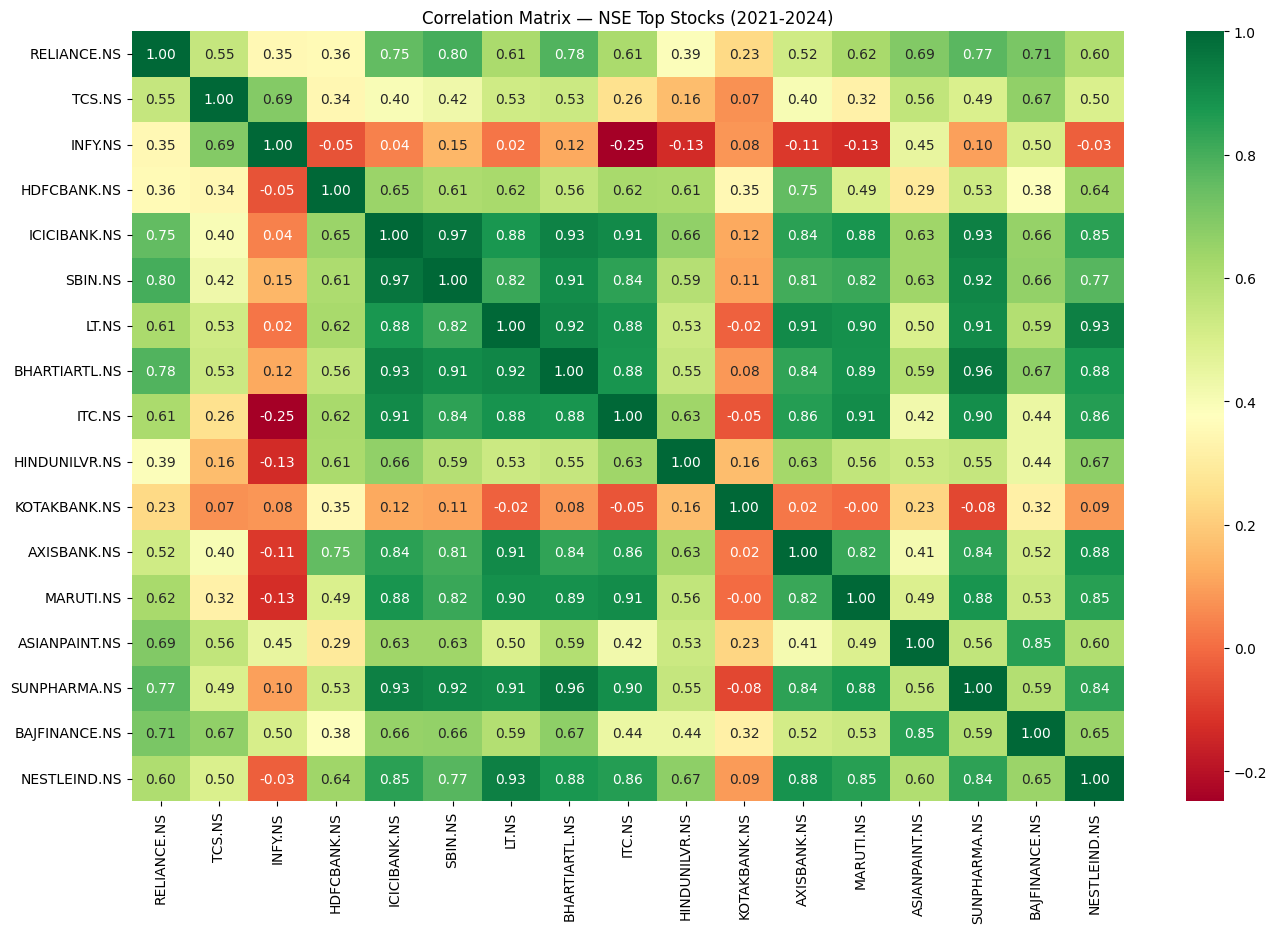

In [19]:
from matplotlib.pyplot import figure

figure(figsize=(16,10), dpi=100)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Correlation Matrix — NSE Top Stocks (2021-2024)")
plt.show()

Text(0, 0.5, 'Price (₹)')

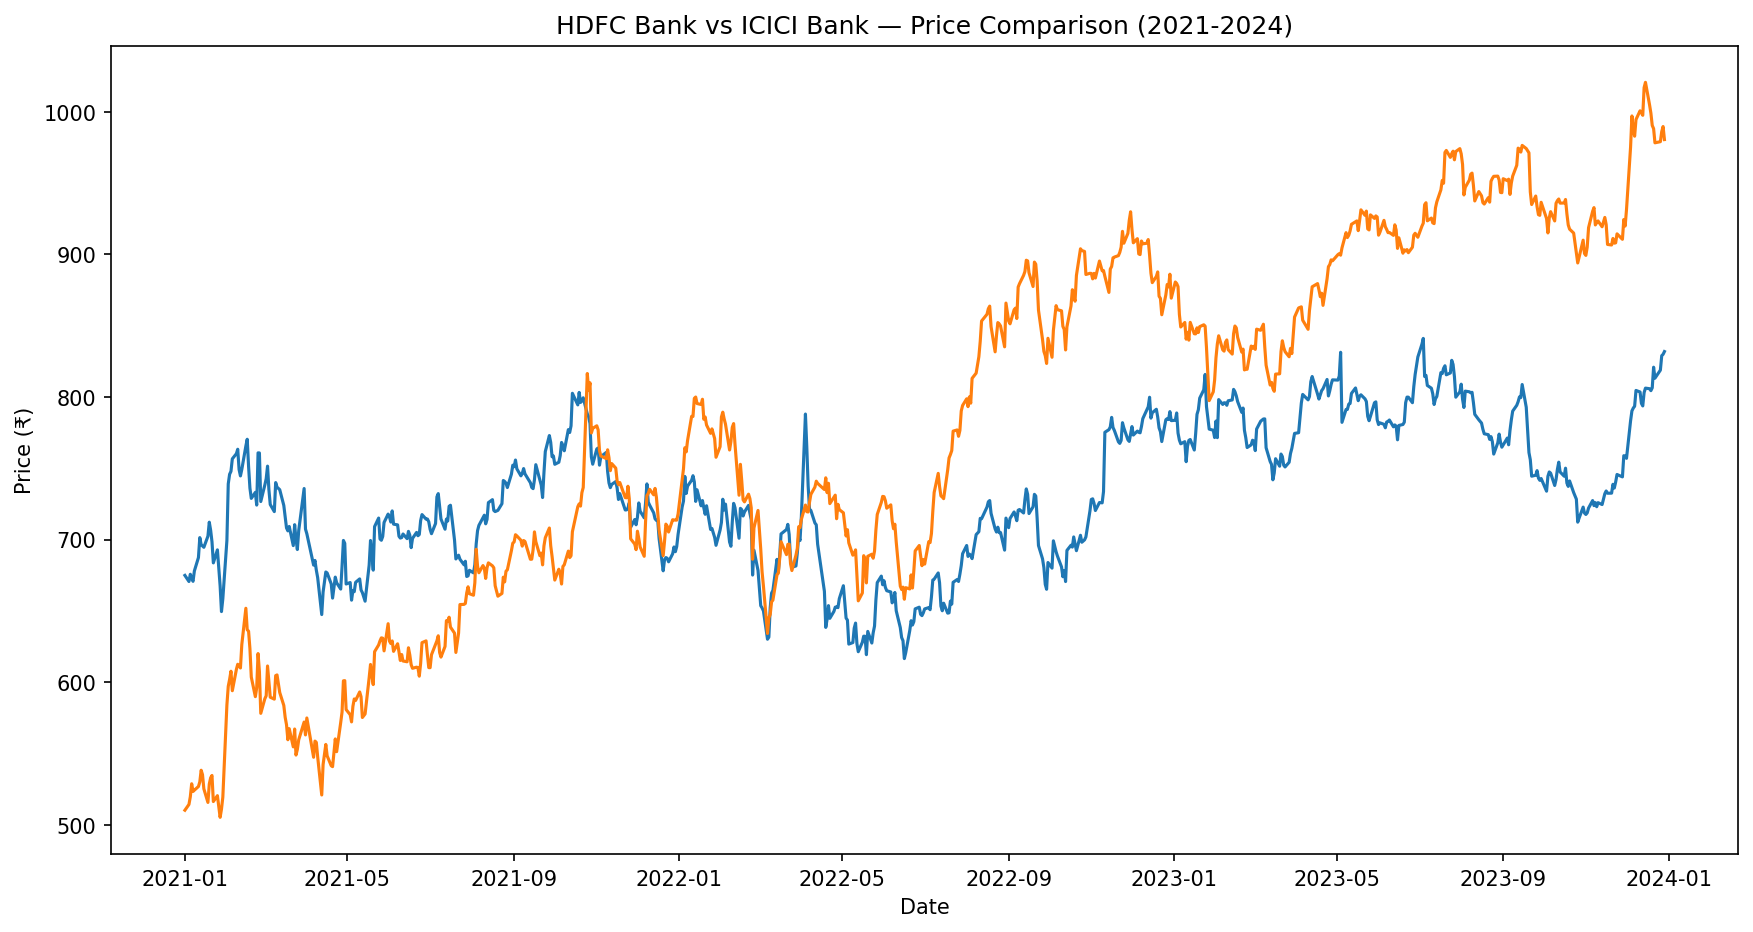

In [21]:
from matplotlib.pyplot import figure

figure(figsize=(14,7), dpi=150)

HDFCBANK = d['HDFCBANK.NS']
ICICIBANK = d['ICICIBANK.NS']

plt.plot(HDFCBANK, label="HDFC Bank")
plt.plot(ICICIBANK, label="ICICI Bank")

plt.title("HDFC Bank vs ICICI Bank — Price Comparison (2021-2024)")
plt.xlabel("Date")plt.ylabel("Price (₹)")

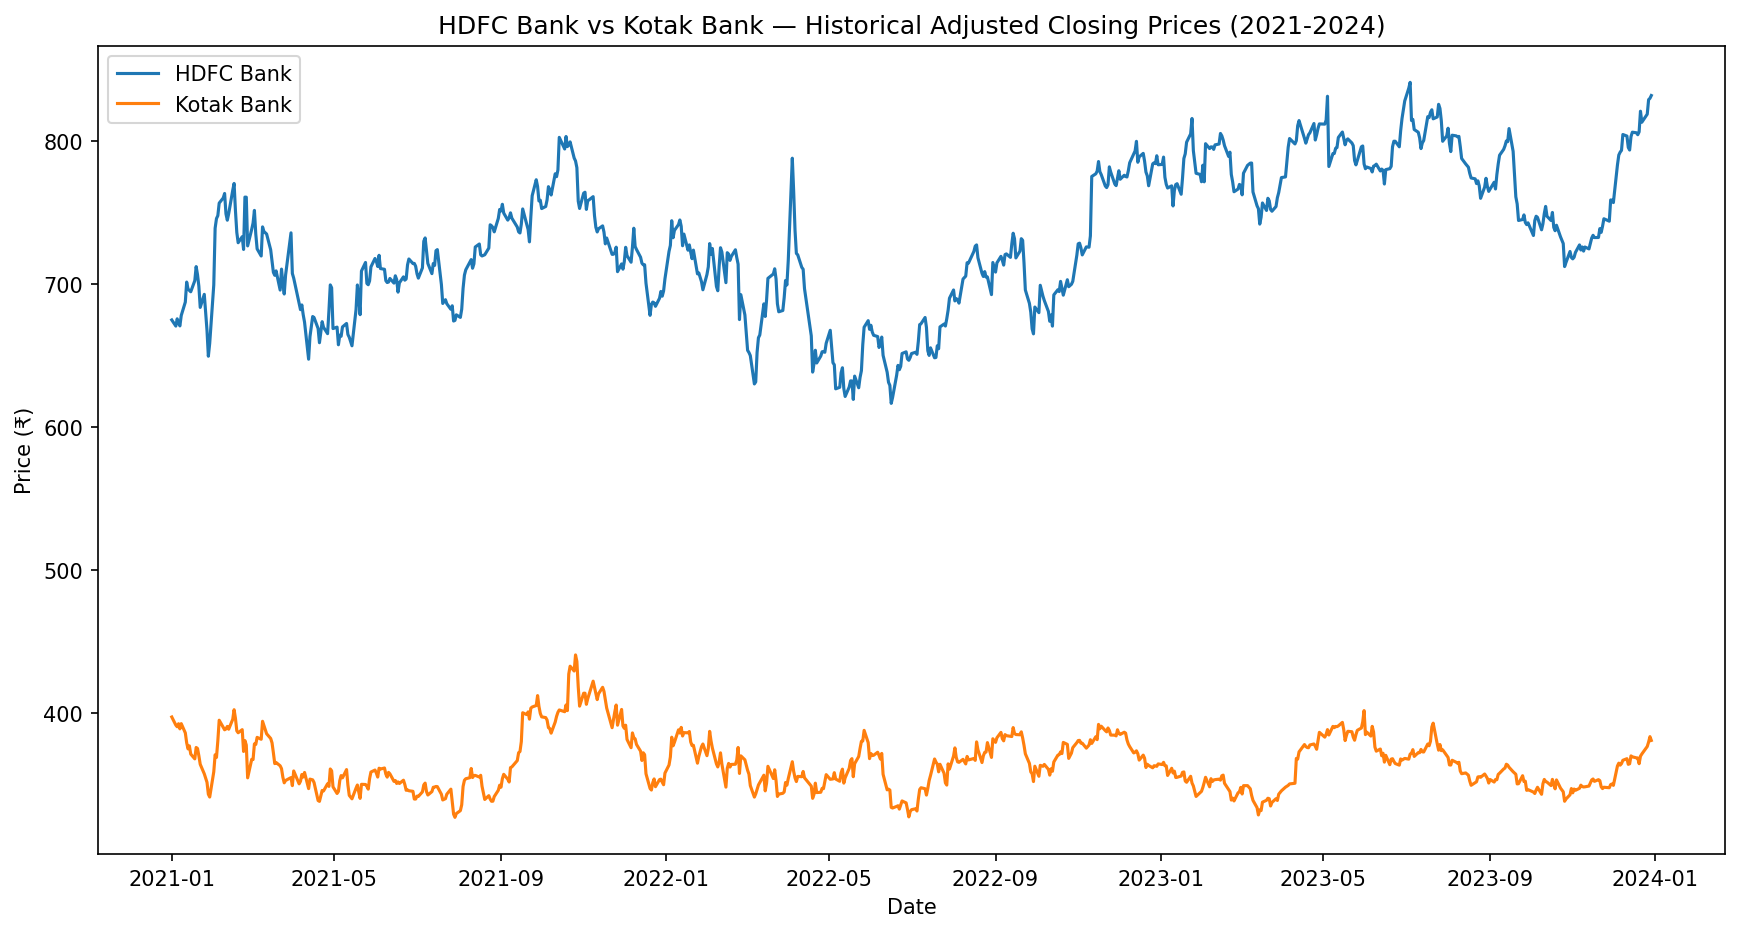

In [22]:
figure(figsize=(14, 7), dpi=150)

HDFCBANK = d['HDFCBANK.NS']
KOTAKBANK = d['KOTAKBANK.NS']

plt.plot(HDFCBANK, label="HDFC Bank")
plt.plot(KOTAKBANK, label="Kotak Bank")

plt.title('HDFC Bank vs Kotak Bank — Historical Adjusted Closing Prices (2021-2024)')
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

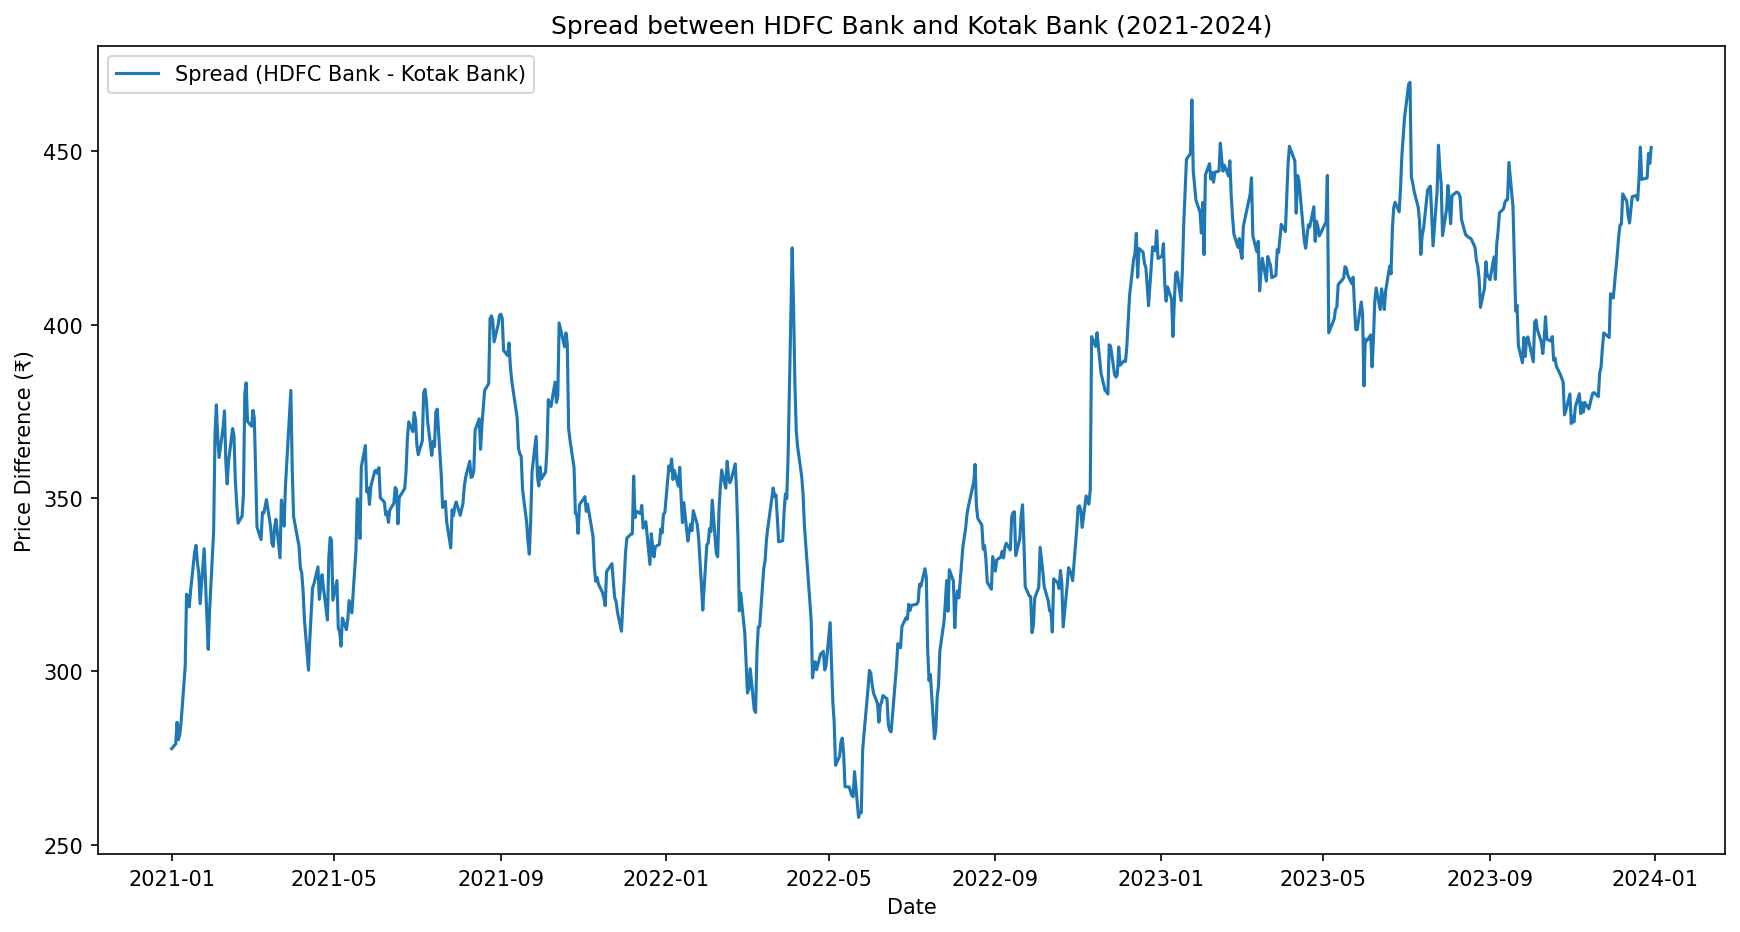

In [23]:
figure(figsize=(14, 7), dpi=150)

plt.plot(HDFCBANK - KOTAKBANK, label='Spread (HDFC Bank - Kotak Bank)')

plt.xlabel("Date")
plt.ylabel("Price Difference (₹)")
plt.legend()
plt.title("Spread between HDFC Bank and Kotak Bank (2021-2024)")

plt.show()

In [27]:
import statsmodels.tsa.stattools as ts
result = ts.coint(HDFCBANK, KOTAKBANK)
print(result)

(np.float64(-2.4361991576854183), np.float64(0.3079074418809967), array([-3.91130109, -3.34439935, -3.05018632]))


In [28]:
cointegration_t_statistic = result[0]
p_val = result[1]
critical_values_test_statistic_at_1_5_10 = result[2]

print('We want P value < 0.05 (meaning cointegration may exist)')
print('P value for HDFC Bank and Kotak Bank cointegration test:', p_val)

We want P value < 0.05 (meaning cointegration may exist)
P value for HDFC Bank and Kotak Bank cointegration test: 0.3079074418809967


In [29]:
from statsmodels.tsa.stattools import adfuller

# ADF for HDFC Bank
HDFCBANK_ADF = adfuller(HDFCBANK)
print('P value for HDFC Bank ADF Test:', HDFCBANK_ADF[1])

# ADF for Kotak Bank
KOTAKBANK_ADF = adfuller(KOTAKBANK)
print('P value for Kotak Bank ADF Test:', KOTAKBANK_ADF[1])

# ADF for Spread
Spread_ADF = adfuller(HDFCBANK - KOTAKBANK)
print('P value for Spread ADF Test:', Spread_ADF[1])

# ADF for Ratio
Ratio_ADF = adfuller(HDFCBANK / KOTAKBANK)
print('P value for Ratio ADF Test:', Ratio_ADF[1])

# Interpretation:
# P-value < 0.05 → stationary
# P-value > 0.05 → non-stationary

P value for HDFC Bank ADF Test: 0.11712086967223156
P value for Kotak Bank ADF Test: 0.0015909457348698447
P value for Spread ADF Test: 0.12807211722171263
P value for Ratio ADF Test: 0.036034424206818835


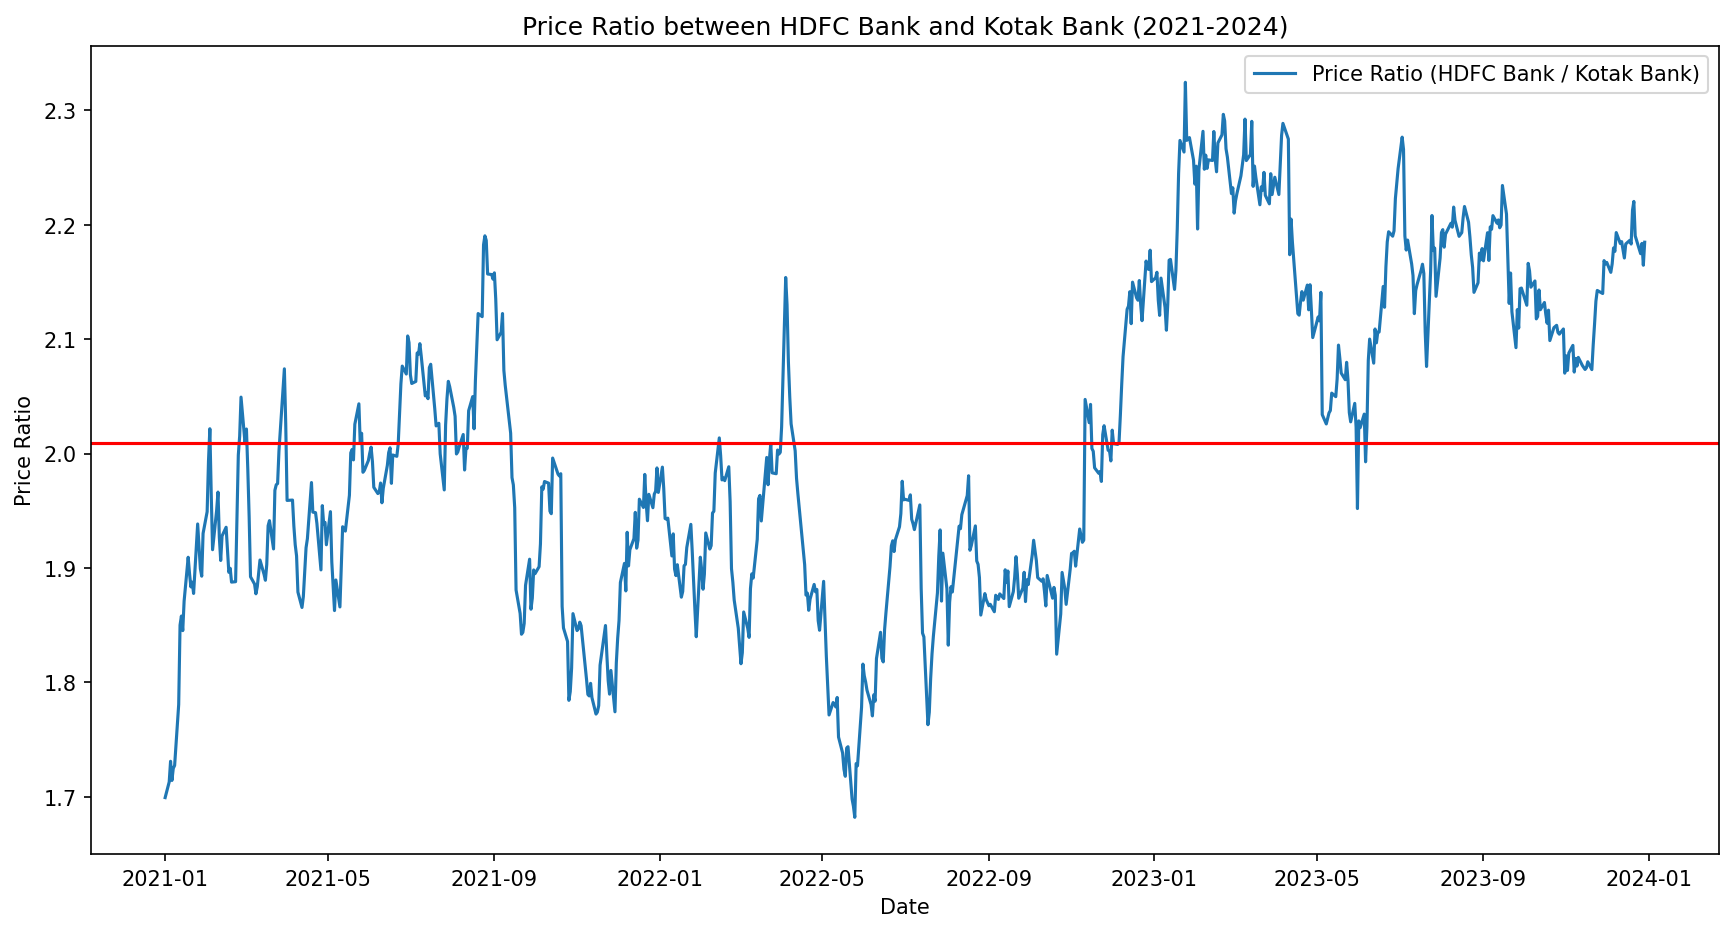

In [30]:
figure(figsize=(14, 7), dpi=150)

ratio = HDFCBANK / KOTAKBANK

plt.plot(ratio, label='Price Ratio (HDFC Bank / Kotak Bank)')
plt.axhline(ratio.mean(), color='red')

plt.xlabel("Date")
plt.ylabel("Price Ratio")
plt.legend()
plt.title("Price Ratio between HDFC Bank and Kotak Bank (2021-2024)")

plt.show()

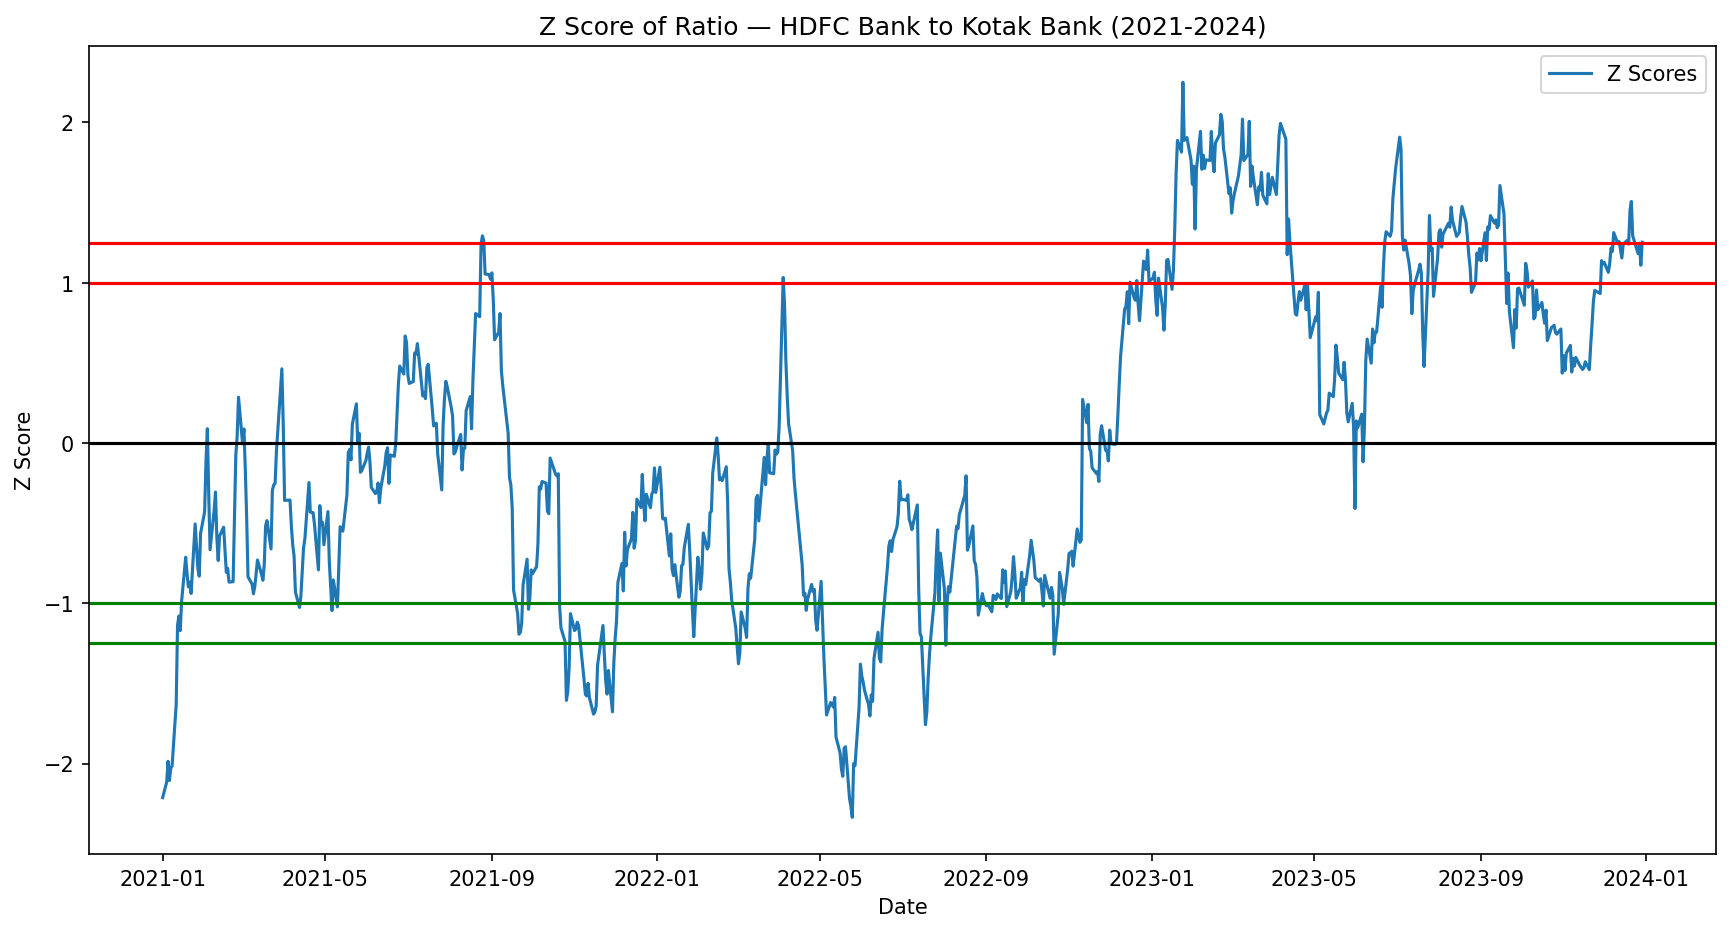

In [31]:
figure(figsize=(14, 7), dpi=150)

# Calculate Z-scores
df_zscore = (ratio - ratio.mean()) / ratio.std()

plt.plot(df_zscore, label="Z Scores")

plt.axhline(df_zscore.mean(), color='black')
plt.axhline(1.0, color='red')
plt.axhline(1.25, color='red')

plt.axhline(-1.0, color='green')
plt.axhline(-1.25, color='green')

plt.xlabel("Date")
plt.ylabel("Z Score")
plt.legend(loc='best')
plt.title('Z Score of Ratio — HDFC Bank to Kotak Bank (2021-2024)')

plt.show()

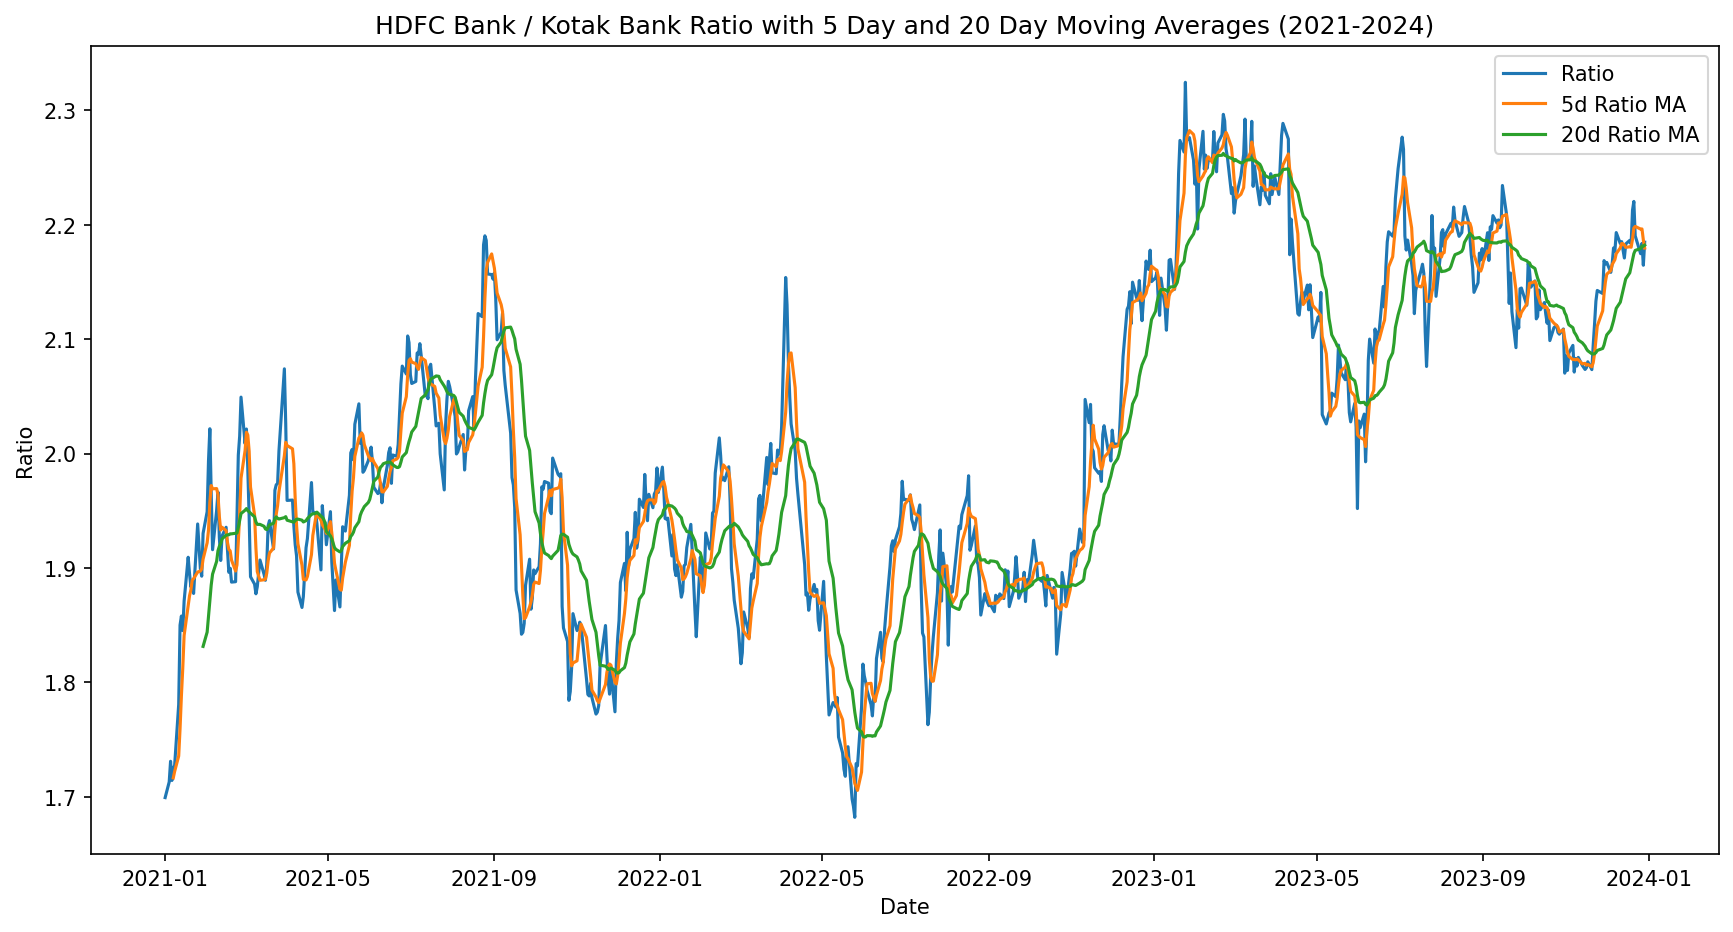

In [32]:
figure(figsize=(14, 7), dpi=150)

ratios_mavg5 = ratio.rolling(window=5, center=False).mean()
ratios_mavg20 = ratio.rolling(window=20, center=False).mean()

std_20 = ratio.rolling(window=20, center=False).std()

zscore_20_5 = (ratios_mavg5 - ratios_mavg20) / std_20

plt.plot(ratio.index, ratio.values)
plt.plot(ratios_mavg5.index, ratios_mavg5.values)
plt.plot(ratios_mavg20.index, ratios_mavg20.values)

plt.legend(['Ratio', '5d Ratio MA', '20d Ratio MA'])

plt.xlabel('Date')
plt.ylabel('Ratio')
plt.title('HDFC Bank / Kotak Bank Ratio with 5 Day and 20 Day Moving Averages (2021-2024)')

plt.show()

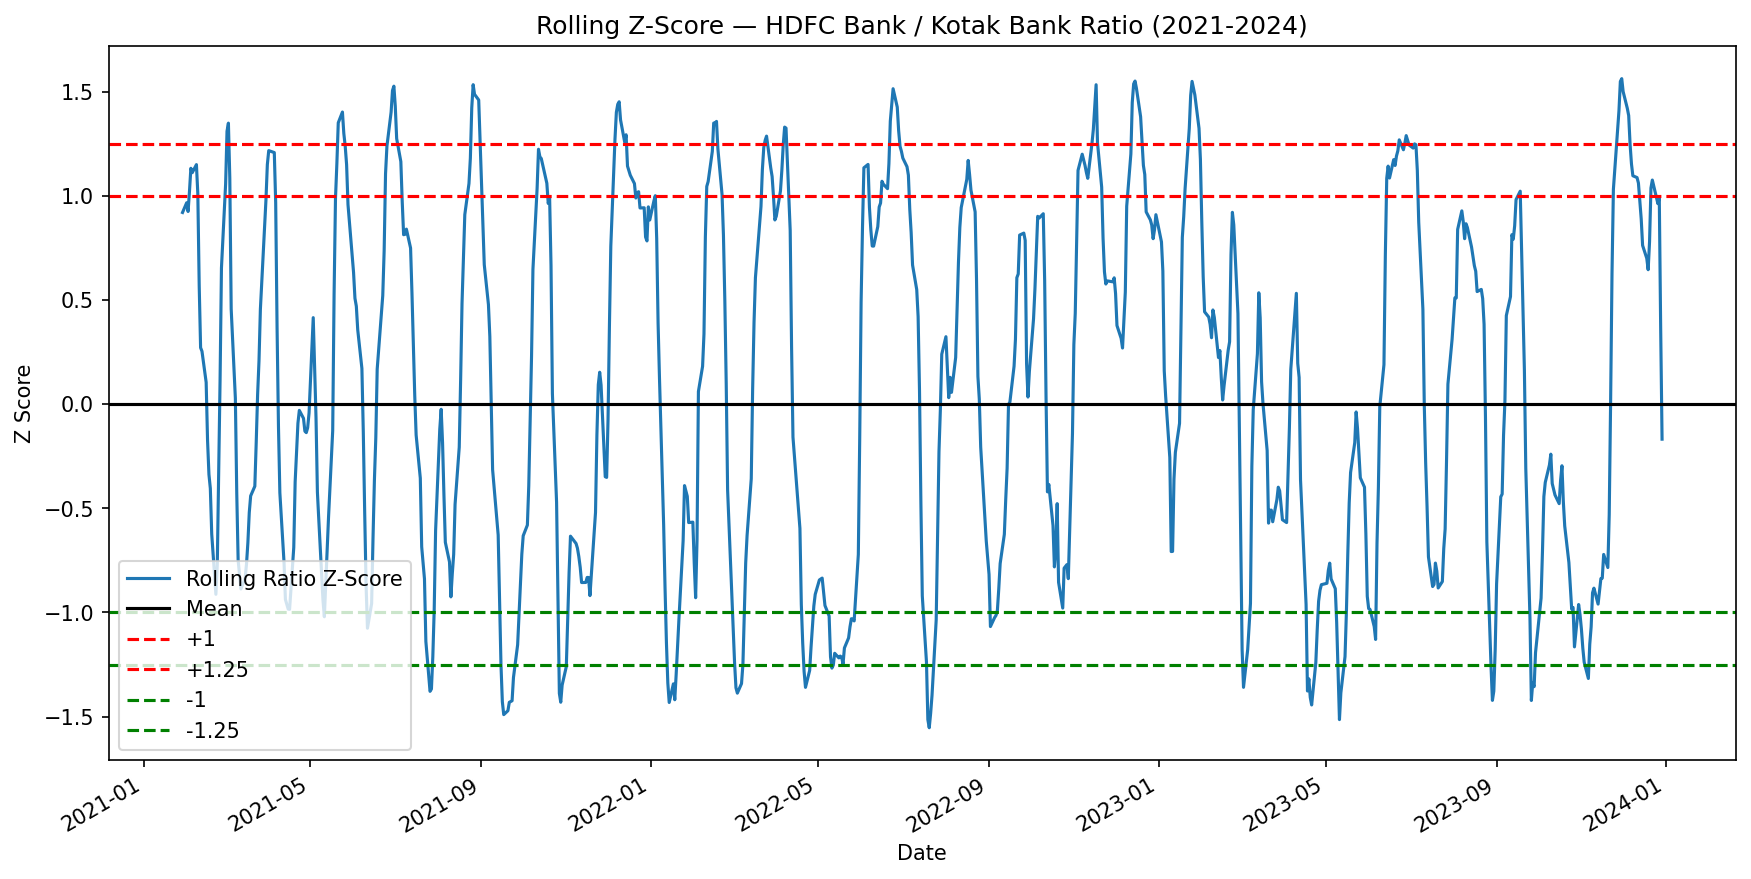

In [33]:
figure(figsize=(14, 7), dpi=150)

zscore_20_5.plot()

plt.axhline(0, color='black')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(1.25, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.axhline(-1.25, color='green', linestyle='--')

plt.xlabel("Date")
plt.ylabel("Z Score")
plt.legend([
    'Rolling Ratio Z-Score',
    'Mean',
    '+1',
    '+1.25',
    '-1',
    '-1.25'
])

plt.title('Rolling Z-Score — HDFC Bank / Kotak Bank Ratio (2021-2024)')

plt.show()

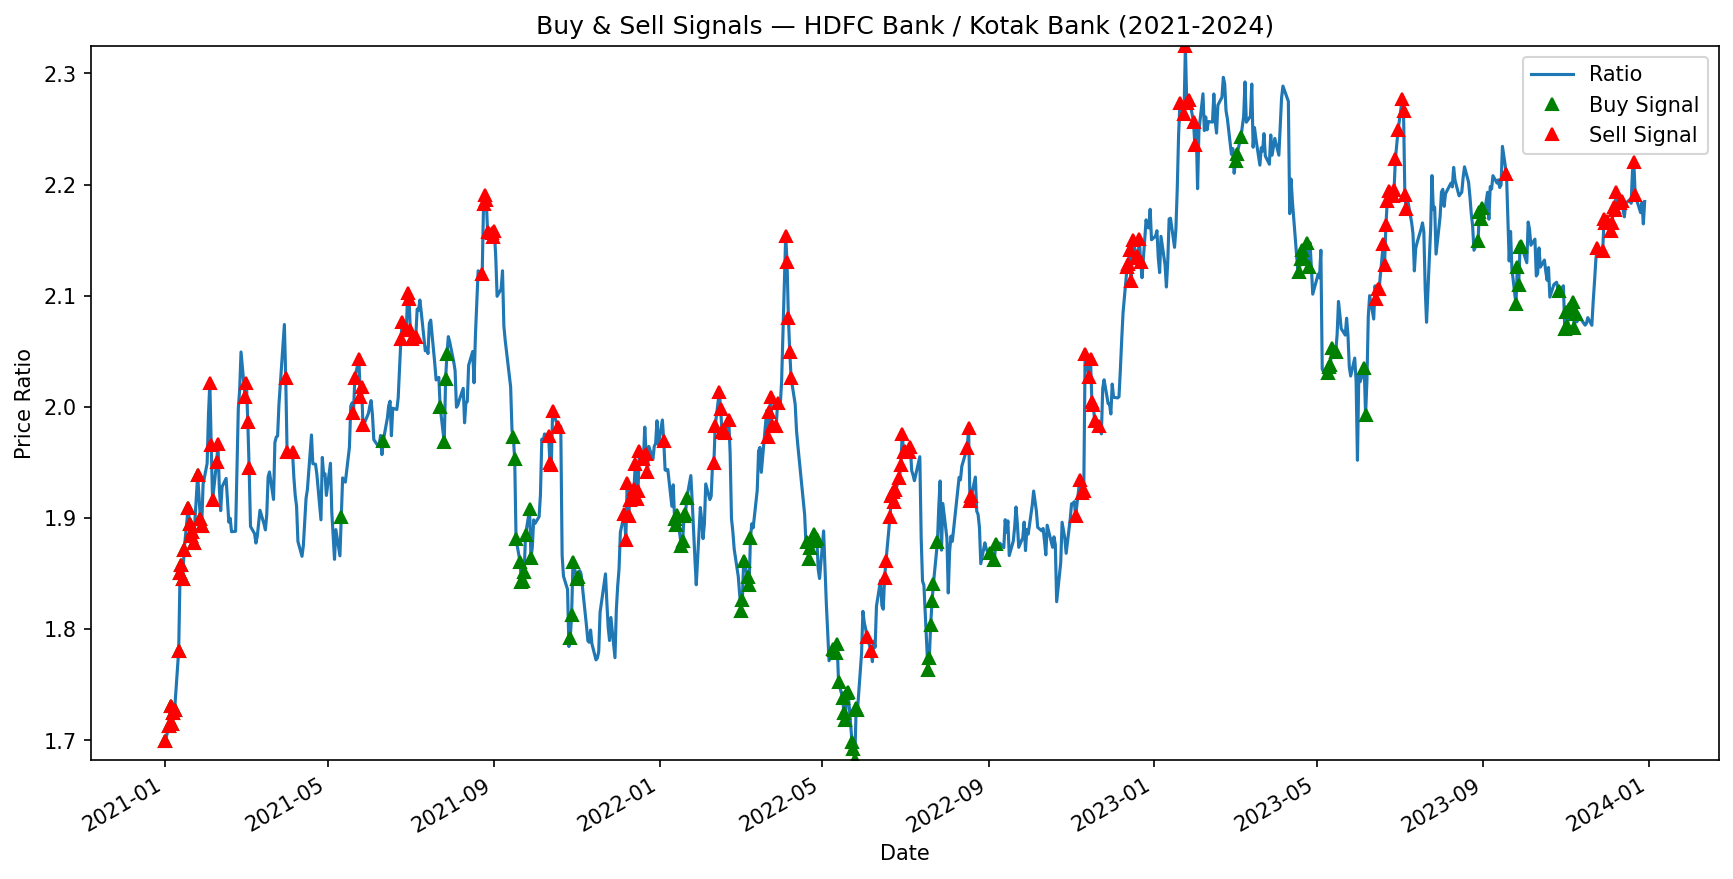

In [34]:
figure(figsize=(14, 7), dpi=150)

ratio.plot()

buy = ratio.copy()
sell = ratio.copy()

buy[zscore_20_5 > -1] = 0
sell[zscore_20_5 < 1] = 0

buy.plot(color='g', linestyle='None', marker='^')
sell.plot(color='r', linestyle='None', marker='^')

x1, x2, y1, y2 = plt.axis()
plt.axis((x1, x2, ratio.min(), ratio.max()))

plt.xlabel("Date")
plt.ylabel("Price Ratio")
plt.legend(['Ratio', 'Buy Signal', 'Sell Signal'])

plt.title('Buy & Sell Signals — HDFC Bank / Kotak Bank (2021-2024)')

plt.show()